In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

# Load the raw dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour, month, and day of the week
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

# Convert unix_time to datetime
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df = df.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift and fill NaN values
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))

# Calculate the time delta in minutes between the previous and current transaction
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60

# Convert columns to datetime and calculate age at the time of transaction
df['dob'] = pd.to_datetime(df['dob'])
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

# Calculate distance from previous merchant
df['prev_merch_lat'] = df.groupby('cc_num')['merch_lat'].shift(1)
df['prev_merch_long'] = df.groupby('cc_num')['merch_long'].shift(1)
df = df.assign(
    prev_merch_lat=df['prev_merch_lat'].fillna(df['merch_lat']),
    prev_merch_long=df['prev_merch_long'].fillna(df['merch_long'])
)
df['distance_from_prev_merch'] = df.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)

# Add domain-specific features
df['trans_frequency'] = df.groupby('cc_num')['trans_date_trans_time'].transform('count')
df['avg_amt_category'] = df.groupby('category')['amt'].transform('mean')

# Create interaction features
df['amt_age_interaction'] = df['amt'] * df['cust_age']
df['amt_distance_interaction'] = df['amt'] * df['distance_from_prev_merch']

# Drop unnecessary columns
drop_cols = ['Unnamed: 0', 'street', 'zip', 'lat', 'long', 'city_pop', 'dob', 'trans_date_trans_time', 
             'unix_time', 'transaction_time', 'merch_lat', 'merch_long', 'cc_num', 'first', 'last']
df = df.drop(columns=drop_cols)

# Split the dataset into training and validation sets
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# One-hot encode the gender column
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')
X_train_gender_encoded = one_hot_encoder.fit_transform(X_train[['gender']])
X_val_gender_encoded = one_hot_encoder.transform(X_val[['gender']])

# Convert the encoded gender columns to DataFrames
X_train_gender_encoded_df = pd.DataFrame(X_train_gender_encoded, columns=one_hot_encoder.get_feature_names_out(['gender']), index=X_train.index)
X_val_gender_encoded_df = pd.DataFrame(X_val_gender_encoded, columns=one_hot_encoder.get_feature_names_out(['gender']), index=X_val.index)

# Drop the original gender column and concatenate the one-hot encoded columns
X_train = pd.concat([X_train.drop(columns=['gender']), X_train_gender_encoded_df], axis=1)
X_val = pd.concat([X_val.drop(columns=['gender']), X_val_gender_encoded_df], axis=1)

# Encode other categorical variables using Label Encoding
label_encoders = {}
categorical_columns = ['merchant', 'category', 'trans_dayofweek', 'job', 'state']

for col in categorical_columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    label_encoders[col] = le

# Ensure all columns are numeric before imputation and scaling
numeric_columns = X_train.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='mean')
X_train[numeric_columns] = imputer.fit_transform(X_train[numeric_columns])
X_val[numeric_columns] = imputer.transform(X_val[numeric_columns])

# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_val_scaled = scaler.transform(X_val[numeric_columns])

# Convert the scaled data back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=numeric_columns, index=X_val.index)

# Display a sample of the final DataFrames
print("Final Training DataFrame Sample:")
print(X_train_scaled_df.head())

print("\nFinal Validation DataFrame Sample:")
print(X_val_scaled_df.head())


Final Training DataFrame Sample:
        merchant  category       amt  state       job  trans_hour  \
332099  0.520231  0.153846  0.002428   0.86  0.677485    0.391304   
13250   0.758671  0.769231  0.000390   0.02  0.890467    0.565217   
85129   0.478324  0.076923  0.000184   0.02  0.661258    0.608696   
325949  0.471098  0.384615  0.001279   0.76  0.900609    0.608696   
903602  0.442197  1.000000  0.000162   0.40  0.649087    0.913043   

        trans_month  trans_dayofweek  unix_time_prev_trans  \
332099     0.454545         0.000000              0.295341   
13250      0.000000         0.833333              0.014801   
85129      0.090909         0.833333              0.093474   
325949     0.454545         0.833333              0.289550   
903602     1.000000         0.000000              0.673746   

        timedelta_last_trans  cust_age  prev_merch_lat  prev_merch_long  \
332099              0.022991  0.146341        0.220231         0.673031   
13250               0.039272 

In [4]:
X_train_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 907672 entries, 332099 to 866833
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   merchant                  907672 non-null  float64
 1   category                  907672 non-null  float64
 2   amt                       907672 non-null  float64
 3   state                     907672 non-null  float64
 4   job                       907672 non-null  float64
 5   trans_hour                907672 non-null  float64
 6   trans_month               907672 non-null  float64
 7   trans_dayofweek           907672 non-null  float64
 8   unix_time_prev_trans      907672 non-null  float64
 9   timedelta_last_trans      907672 non-null  float64
 10  cust_age                  907672 non-null  float64
 11  prev_merch_lat            907672 non-null  float64
 12  prev_merch_long           907672 non-null  float64
 13  distance_from_prev_merch  907672 non-null  f

In [5]:
X_val_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389003 entries, 169757 to 57846
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   merchant                  389003 non-null  float64
 1   category                  389003 non-null  float64
 2   amt                       389003 non-null  float64
 3   state                     389003 non-null  float64
 4   job                       389003 non-null  float64
 5   trans_hour                389003 non-null  float64
 6   trans_month               389003 non-null  float64
 7   trans_dayofweek           389003 non-null  float64
 8   unix_time_prev_trans      389003 non-null  float64
 9   timedelta_last_trans      389003 non-null  float64
 10  cust_age                  389003 non-null  float64
 11  prev_merch_lat            389003 non-null  float64
 12  prev_merch_long           389003 non-null  float64
 13  distance_from_prev_merch  389003 non-null  fl

In [27]:
# Now we apply the same steps to the unseen data
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

# Function to map unseen labels to -1
def map_labels(le, values):
    mapped = []
    for item in values:
        if item in le.classes_:
            mapped.append(le.transform([item])[0])
        else:
            mapped.append(-1)  # Assign -1 to unseen labels
    return np.array(mapped)

# Load the unseen dataset
unseen_df = pd.read_csv('../../data/raw/Fraudtest.csv')

# Split unseen data into features and target
X_unseen = unseen_df.drop(columns=["is_fraud"])
y_unseen = unseen_df["is_fraud"]

# Apply the same preprocessing steps to the unseen data
X_unseen['trans_date_trans_time'] = pd.to_datetime(X_unseen['trans_date_trans_time'])
X_unseen['trans_hour'] = X_unseen['trans_date_trans_time'].dt.hour
X_unseen['trans_month'] = X_unseen['trans_date_trans_time'].dt.month
X_unseen['trans_dayofweek'] = X_unseen['trans_date_trans_time'].dt.day_name()
X_unseen['transaction_time'] = pd.to_datetime(X_unseen['unix_time'], unit='s')
X_unseen = X_unseen.sort_values(by=['cc_num', 'transaction_time'])
X_unseen['unix_time_prev_trans'] = X_unseen.groupby(by=['cc_num'])['unix_time'].shift(1)
X_unseen = X_unseen.assign(unix_time_prev_trans=X_unseen['unix_time_prev_trans'].fillna(X_unseen['unix_time'] - 86400))
X_unseen['timedelta_last_trans'] = (X_unseen['unix_time'] - X_unseen['unix_time_prev_trans']) // 60
X_unseen['dob'] = pd.to_datetime(X_unseen['dob'])
X_unseen['cust_age'] = (X_unseen['trans_date_trans_time'] - X_unseen['dob']).dt.days // 365
X_unseen['prev_merch_lat'] = X_unseen.groupby('cc_num')['merch_lat'].shift(1)
X_unseen['prev_merch_long'] = X_unseen.groupby('cc_num')['merch_long'].shift(1)
X_unseen = X_unseen.assign(
    prev_merch_lat=X_unseen['prev_merch_lat'].fillna(X_unseen['merch_lat']),
    prev_merch_long=X_unseen['prev_merch_long'].fillna(X_unseen['merch_long'])
)
X_unseen['distance_from_prev_merch'] = X_unseen.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)
X_unseen['trans_frequency'] = X_unseen.groupby('cc_num')['trans_date_trans_time'].transform('count')
X_unseen['avg_amt_category'] = X_unseen.groupby('category')['amt'].transform('mean')
X_unseen['amt_age_interaction'] = X_unseen['amt'] * X_unseen['cust_age']
X_unseen['amt_distance_interaction'] = X_unseen['amt'] * X_unseen['distance_from_prev_merch']

# Drop unnecessary columns
drop_cols = ['Unnamed: 0', 'street', 'zip', 'lat', 'long', 'city_pop', 'dob', 'trans_date_trans_time', 
             'unix_time', 'transaction_time', 'merch_lat', 'merch_long', 'cc_num', 'first', 'last']
X_unseen = X_unseen.drop(columns=drop_cols)

# One-hot encode the gender column using the same encoder
unseen_gender_encoded = one_hot_encoder.transform(X_unseen[['gender']])
unseen_gender_encoded_df = pd.DataFrame(unseen_gender_encoded, columns=one_hot_encoder.get_feature_names_out(['gender']), index=X_unseen.index)
X_unseen = pd.concat([X_unseen.drop(columns=['gender']), unseen_gender_encoded_df], axis=1)

# Encode other categorical variables using the same Label Encoders, handle unseen labels
for col in categorical_columns:
    le = label_encoders[col]
    X_unseen[col] = map_labels(le, X_unseen[col])

# Ensure all columns are numeric before imputation and scaling
numeric_columns_unseen = X_unseen.select_dtypes(include=[np.number]).columns

X_unseen[numeric_columns_unseen] = imputer.transform(X_unseen[numeric_columns_unseen])

# Scale the features
unseen_scaled = scaler.transform(X_unseen[numeric_columns_unseen])

# Convert the scaled data back to a DataFrame
X_unseen_scaled_df = pd.DataFrame(unseen_scaled, columns=numeric_columns_unseen, index=X_unseen.index)

# Display a sample of the final DataFrame for unseen data
print("\nFinal Unseen DataFrame Sample:")
print(X_unseen_scaled_df.head())


Final Unseen DataFrame Sample:
      merchant  category       amt  state       job  trans_hour  trans_month  \
157   0.523121  0.461538  0.004515    1.0  0.498986    0.565217     0.454545   
741   0.325145  0.692308  0.002830    1.0  0.498986    0.695652     0.454545   
3047  0.148844  0.153846  0.002346    1.0  0.498986    0.304348     0.454545   
4351  0.539017  0.538462  0.003167    1.0  0.498986    0.652174     0.454545   
7695  0.552023  0.769231  0.005368    1.0  0.498986    0.521739     0.454545   

      trans_dayofweek  unix_time_prev_trans  timedelta_last_trans  cust_age  \
157          0.500000              0.998240              0.064409  0.256098   
741          0.500000              1.000097              0.008901  0.256098   
3047         0.166667              1.000355              0.041687  0.256098   
4351         0.166667              1.001558              0.020262  0.256098   
7695         0.833333              1.002143              0.056179  0.256098   

      prev_m

In [28]:
X_unseen_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 157 to 553883
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   merchant                  555719 non-null  float64
 1   category                  555719 non-null  float64
 2   amt                       555719 non-null  float64
 3   state                     555719 non-null  float64
 4   job                       555719 non-null  float64
 5   trans_hour                555719 non-null  float64
 6   trans_month               555719 non-null  float64
 7   trans_dayofweek           555719 non-null  float64
 8   unix_time_prev_trans      555719 non-null  float64
 9   timedelta_last_trans      555719 non-null  float64
 10  cust_age                  555719 non-null  float64
 11  prev_merch_lat            555719 non-null  float64
 12  prev_merch_long           555719 non-null  float64
 13  distance_from_prev_merch  555719 non-null  floa

# Model building and testing 
#### 1. XGBoost without resampling method

Scale Pos Weight: 13.105658297322067
Estimate for scale_pos_weight: 13.106
Validation Accuracy: 0.9987429402858076
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.87      0.92      0.89      2252

    accuracy                           1.00    389003
   macro avg       0.94      0.96      0.95    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
 [[386448    303]
 [   186   2066]]
Validation ROC AUC Score: 0.9989405327975881
Validation PR AUC Score: 0.961451153897224


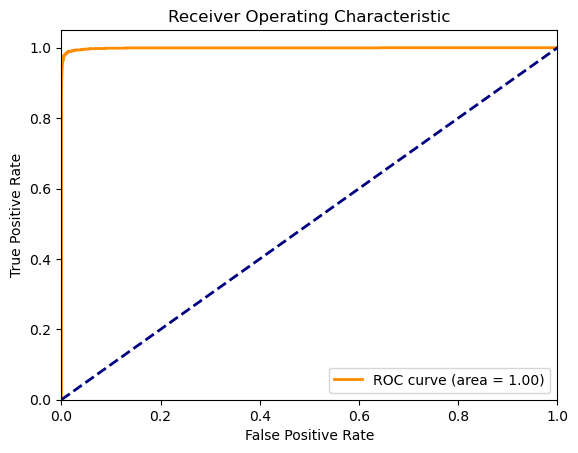

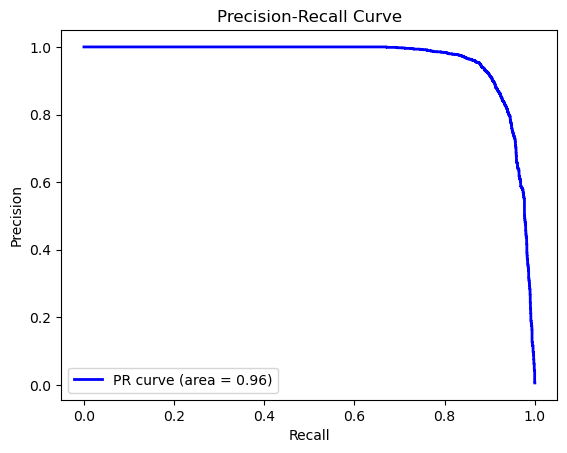

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from collections import Counter
import numpy as np

# Calculate scale_pos_weight using the square root of the ratio
counter = Counter(y_train)
scale_pos_weight = np.sqrt(counter[0] / counter[1])

print("Scale Pos Weight:", scale_pos_weight)
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9831749499297306
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.00      0.01      0.01      2145

    accuracy                           0.98    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      0.98      0.99    555719

Unseen Data Confusion Matrix:
 [[546339   7235]
 [  2115     30]]
Unseen Data ROC AUC Score: 0.5009817252539996
Unseen Data PR AUC Score: 0.003906677058535464


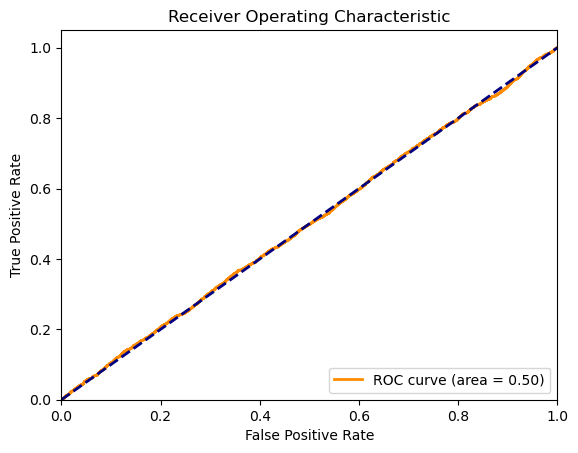

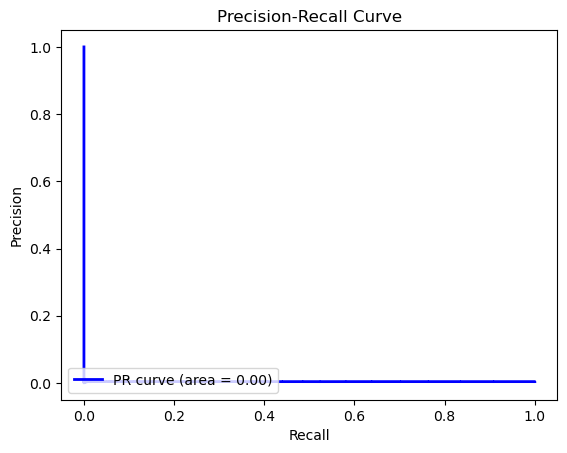

In [30]:
# Make predictions on the unseen data with the base model
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [31]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9996 ± 0.0000, Test: 0.9987 ± 0.0001
Precision - Train: 0.9367 ± 0.0029, Test: 0.8731 ± 0.0099
Recall - Train: 0.9998 ± 0.0002, Test: 0.9094 ± 0.0046
F1 - Train: 0.9672 ± 0.0016, Test: 0.8909 ± 0.0060
Roc_auc - Train: 1.0000 ± 0.0000, Test: 0.9988 ± 0.0003
CPU times: total: 2min 30s
Wall time: 11.6 s


In [11]:
%%time
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import joblib
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

# Define the XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',  # Optimize for roc_auc
    n_jobs=-1,  # Use all available processors
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search
bayes_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)


C:\Users\Black\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:43:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: OrderedDict([('learning_rate', 0.2), ('max_depth', 25), ('n_estimators', 200), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score: 0.9988726460421015
CPU times: total: 1min 29s
Wall time: 9min 48s


Unseen Data Accuracy (Fixed Threshold): 0.9887982955414517
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.00      0.01      0.00      2145

    accuracy                           0.99    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      0.99      0.99    555719

Unseen Data Confusion Matrix (Fixed Threshold):
TN: 549483, FP: 4091, FN: 2134, TP: 11
[[549483   4091]
 [  2134     11]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.4941939394747872
Unseen Data PR AUC Score (Fixed Threshold): 0.0038358629618190847


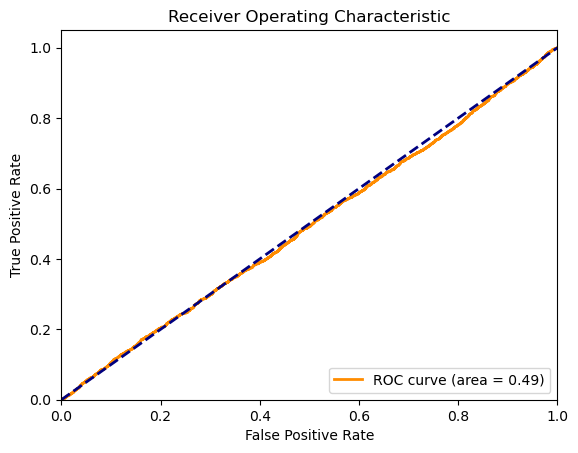

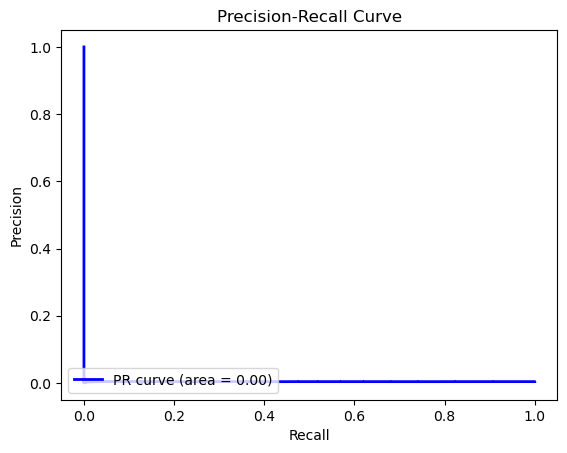

In [12]:
# Use the best model for predictions
best_xgb_model = bayes_search.best_estimator_

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Apply the fixed threshold of 0.6 to the predictions
fixed_threshold = 0.6
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Apply the fixed threshold of 0.6 to the predictions
fixed_threshold = 0.6
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

******************
#### Using stacking classifier

In [32]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix
import numpy as np

# Calculate scale_pos_weight using the given formula
scale_pos_weight = np.sqrt((y_train == 0).sum() / (y_train == 1).sum())

# Define base models
base_models = [
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lgb', lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
]

# Define stacking classifier
stack_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# Train stacking model
stack_model.fit(X_train_scaled_df, y_train)

# Model Evaluation
y_pred = stack_model.predict(X_val_scaled_df)
y_pred_prob = stack_model.predict_proba(X_val_scaled_df)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_prob)
pr_auc = auc(recall_vals, precision_vals)

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')
print("Classification Report:")
print(classification_report(y_val, y_pred))
print("Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

C:\Users\Black\anaconda3\Lib\site-packages\dask\dataframe\_pyarrow_compat.py:23: UserWarning: You are using pyarrow version 11.0.0 which is known to be insecure. See https://www.cve.org/CVERecord?id=CVE-2023-47248 for further details. Please upgrade to pyarrow>=14.0.1 or install pyarrow-hotfix to patch your current version.
  warnings.warn(


[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005473 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2994
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005788 -> initscore=-5.146088
[LightGBM] [Info] Start training from score -5.146088
[LightGBM] [Info] Number of positive: 4203, number of negative: 721934
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2995
[LightGBM] [Info] Number of data points in the train set: 726137, number of used features: 19
[LightGBM] [Info

In [33]:
# Model Evaluation on Unseen Data
y_unseen_pred = stack_model.predict(X_unseen_scaled_df)
y_unseen_pred_prob = stack_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Calculate Metrics
accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_prob)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_prob)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion Matrix for Unseen Data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Accuracy (Unseen): {accuracy_unseen:.4f}')
print(f'Precision (Unseen): {precision_unseen:.4f}')
print(f'Recall (Unseen): {recall_unseen:.4f}')
print(f'F1 Score (Unseen): {f1_unseen:.4f}')
print(f'ROC-AUC (Unseen): {roc_auc_unseen:.4f}')
print(f'PR AUC (Unseen): {pr_auc_unseen:.4f}')
print("Classification Report (Unseen):")
print(classification_report(y_unseen, y_unseen_pred))
print("Confusion Matrix (Unseen):")
print(conf_matrix_unseen)
print(f'True Positives (TP) (Unseen): {tp_unseen}')
print(f'False Positives (FP) (Unseen): {fp_unseen}')
print(f'True Negatives (TN) (Unseen): {tn_unseen}')
print(f'False Negatives (FN) (Unseen): {fn_unseen}')


Accuracy (Unseen): 0.9889
Precision (Unseen): 0.0039
Recall (Unseen): 0.0075
F1 Score (Unseen): 0.0052
ROC-AUC (Unseen): 0.4977
PR AUC (Unseen): 0.0039
Classification Report (Unseen):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.00      0.01      0.01      2145

    accuracy                           0.99    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      0.99      0.99    555719

Confusion Matrix (Unseen):
[[549522   4052]
 [  2129     16]]
True Positives (TP) (Unseen): 16
False Positives (FP) (Unseen): 4052
True Negatives (TN) (Unseen): 549522
False Negatives (FN) (Unseen): 2129


In [34]:
%%time
from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import joblib

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the parameter grid for XGBoost
xgb_param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

# Initialize the Bayesian Search CV for XGBoost
xgb_bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=xgb_param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=-1,
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search for XGBoost
with joblib.parallel_backend('threading'):
    xgb_bayes_search.fit(X_train_scaled_df, y_train)

# Best parameters and score for XGBoost
print("Best Parameters for XGBoost:", xgb_bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score for XGBoost:", xgb_bayes_search.best_score_)

# Define the parameter grid for LightGBM
lgb_param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42)

# Initialize the Bayesian Search CV for LightGBM
lgb_bayes_search = BayesSearchCV(
    estimator=lgb_model,
    search_spaces=lgb_param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=-1,
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search for LightGBM
with joblib.parallel_backend('threading'):
    lgb_bayes_search.fit(X_train_scaled_df, y_train)

# Best parameters and score for LightGBM
print("Best Parameters for LightGBM:", lgb_bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score for LightGBM:", lgb_bayes_search.best_score_)

Best Parameters for XGBoost: OrderedDict([('learning_rate', 0.2), ('max_depth', 25), ('n_estimators', 200), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score for XGBoost: 0.9988726460421015
[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004004 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2994
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005788 -> initscore=-5.146088
[LightGBM] [Info] Start training from score -5.146088
Best Parameters for LightGBM: OrderedDict([('learning_rate', 0.03416312199509112), ('max_depth', 22), ('n_estimators', 190), ('scale_pos_weight', 316)])
Best Cross-Validation ROC AUC Score for LightGBM: 0.9980717536018231
CPU times: total:

In [35]:
%%time
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix
import numpy as np

# Initialize the tuned base models
tuned_xgb_model = xgb.XGBClassifier(**xgb_bayes_search.best_params_)
tuned_lgb_model = lgb.LGBMClassifier(**lgb_bayes_search.best_params_)

# Define base models
base_models = [
    ('xgb', tuned_xgb_model),
    ('lgb', tuned_lgb_model)
]

# Define stacking classifier
stack_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# Apply ADASYN
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled_df, y_train)

# Train stacking model with resampled data
stack_model.fit(X_resampled, y_resampled)

# Model Evaluation on Validation Data
y_pred = stack_model.predict(X_val_scaled_df)
y_pred_prob = stack_model.predict_proba(X_val_scaled_df)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_prob)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')
print("Classification Report:")
print(classification_report(y_val, y_pred))
print("Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')


[LightGBM] [Info] Number of positive: 902898, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4583
[LightGBM] [Info] Number of data points in the train set: 1805316, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500133 -> initscore=0.000532
[LightGBM] [Info] Start training from score 0.000532
[LightGBM] [Info] Number of positive: 722318, number of negative: 721934
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4584
[LightGBM] [Info] Number of data points in the train set: 1444252, number of used features: 19
[LightGBM] [

In [36]:
# Model Evaluation on Unseen Data
y_unseen_pred = stack_model.predict(X_unseen_scaled_df)
y_unseen_pred_prob = stack_model.predict_proba(X_unseen_scaled_df)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_prob)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_prob)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Accuracy (Unseen): {accuracy_unseen:.4f}')
print(f'Precision (Unseen): {precision_unseen:.4f}')
print(f'Recall (Unseen): {recall_unseen:.4f}')
print(f'F1 Score (Unseen): {f1_unseen:.4f}')
print(f'ROC-AUC (Unseen): {roc_auc_unseen:.4f}')
print(f'PR AUC (Unseen): {pr_auc_unseen:.4f}')
print("Classification Report (Unseen):")
print(classification_report(y_unseen, y_unseen_pred))
print("Confusion Matrix (Unseen):")
print(conf_matrix_unseen)
print(f'True Positives (TP) (Unseen): {tp_unseen}')
print(f'False Positives (FP) (Unseen): {fp_unseen}')
print(f'True Negatives (TN) (Unseen): {tn_unseen}')
print(f'False Negatives (FN) (Unseen): {fn_unseen}')

Accuracy (Unseen): 0.6743
Precision (Unseen): 0.0040
Recall (Unseen): 0.3343
F1 Score (Unseen): 0.0079
ROC-AUC (Unseen): 0.5071
PR AUC (Unseen): 0.0039
Classification Report (Unseen):
              precision    recall  f1-score   support

           0       1.00      0.68      0.81    553574
           1       0.00      0.33      0.01      2145

    accuracy                           0.67    555719
   macro avg       0.50      0.50      0.41    555719
weighted avg       0.99      0.67      0.80    555719

Confusion Matrix (Unseen):
[[373979 179595]
 [  1428    717]]
True Positives (TP) (Unseen): 717
False Positives (FP) (Unseen): 179595
True Negatives (TN) (Unseen): 373979
False Negatives (FN) (Unseen): 1428
